# Source similarity

Construct bipartite graph:  
Nodes:  
- sources 
- Cantus IDs (CID)
Edges:
- edge between source and feast is present, if some chants dedicated to such feast are present in the catalogued source
- edge weight == log2(number of chants with unique CIDs)

Run SBM for weighted graph - try both basic and nested PLUS degree corrected versions.

In [30]:
import utils

In [31]:
import pycantus
import pycantus.data as data

In [32]:
corpus = data.load_dataset('cantuscorpus_v1.0')

Loading chants and sources...
Data loaded!


In [33]:
n_chants = len(corpus.chants)
print(f'Number of chants in CantusCorpus v1.0: {n_chants}')
n_sources = len(corpus.sources)
print(f'Number of sources in CantusCorpus v1.0: {n_sources}')

Number of chants in CantusCorpus v1.0: 888010
Number of sources in CantusCorpus v1.0: 2278


In [34]:
# Drop doxology
doxo_filter = pycantus.filtration.Filter('doxo_filter')
doxo_filter.add_value_exclude('cantus_id', '909000')
corpus.apply_filter(doxo_filter)

In [35]:
# Drop fragments => sources with less than 100 chants
corpus.drop_small_sources_data(min_chants=100)

In [36]:
n_chants = len(corpus.chants)
print(f'Number of chants in CantusCorpus v1.0: {n_chants}')
n_sources = len(corpus.sources)
print(f'Number of sources in CantusCorpus v1.0: {n_sources}')

Number of chants in CantusCorpus v1.0: 855146
Number of sources in CantusCorpus v1.0: 510


Create network

In [37]:
import importlib
importlib.reload(utils)

<module 'utils' from '/home/ana/Desktop/ChantNets/experiments/utils.py'>

In [40]:
graph = utils.construct_bipart_source_feast_graph(corpus)

Constructing bipartite graph between sources and feasts...
Number of source nodes: 507
Number of feast nodes: 2371
Number of source-feast edges: 65700


In [41]:
print(f'Number of vertices: {graph.num_vertices()}')
print(f'Number of edges: {graph.num_edges()}')

Number of vertices: 2878
Number of edges: 65700


In [42]:
utils.save_graph(graph, "nets/source_feast_bi_graph.gt")

### Add SBM

In [43]:
import sbmodel
importlib.reload(sbmodel)

<module 'sbmodel' from '/home/ana/Desktop/ChantNets/experiments/sbmodel.py'>

In [44]:
model = sbmodel.SBModel()
model.load_graph('nets/source_feast_bi_graph.gt')

Loaded graph with 2878 vertices, 65700 edges


In [45]:
model.fit_sbm(n_init=3)

Fitting SBM to graph with 2878 vertices and 65700 edges...
Fitting SBM (init 1/3)...
[1/3] entropy = 134947.22
Fitting SBM (init 2/3)...
[2/3] entropy = 134936.87
Fitting SBM (init 3/3)...
[3/3] entropy = 134896.03


In [46]:
model.save_states("models/dc_sbm_model.pickle")

In [47]:
model.fit_nested_sbm(n_init=3)

Fitting nested SBM to graph with 2878 vertices and 65700 edges...
Fitting nested SBM (init 1/3)...
[1/3] entropy = 130495.67
Fitting nested SBM (init 2/3)...
[2/3] entropy = 130900.71
Fitting nested SBM (init 3/3)...
[3/3] entropy = 130847.11


In [48]:
model.save_states("models/nested_dc_sbm_model.pickle")

## Visualization

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sbmodel import SBModel


def load_models(paths):
    """Load models and return entropy traces."""
    out = {}
    for name, path in paths.items():
        m = SBModel()
        m.load_states(path)
        #print(m.states)
        out[name] = [float(e['model']) for e in m.get_states()[name]]
    print(f"Loaded models: {list(out.keys())}")
    print(f"Number of runs per model: {[len(vals) for vals in out.values()]}")
    return out


def compute_log_odds(entropies):
    """Convert entropies to log-likelihood odds."""
    sigma_min = min(v for runs in entropies.values() for v in runs)
    return {
        m: [(val - sigma_min) * -np.log10(2.0) for val in vals]
        for m, vals in entropies.items()
    }


def plot_model_comparison(log_odds, out_path):
    """Plot log-likelihood differences across models."""
    cmap = plt.colormaps['Dark2']
    colours = {m: cmap(i / len(log_odds)) for i, m in enumerate(log_odds)}

    fig, ax = plt.subplots(figsize = (10, 2), constrained_layout = True)
    ax.axhline(0, color='black', linewidth=1)

    for model, xs in log_odds.items():
        ax.scatter(xs, np.zeros_like(xs), s=60, zorder=3, color=colours[model], alpha=0.3)

    for model, xs in log_odds.items():
        ax.text(np.median(xs), 0.14, model, ha='center', va='bottom', fontsize=12, color=colours[model])

    all_vals = np.concatenate(list(log_odds.values()))
    ticks = np.arange(
        int(200 * np.floor(all_vals.min() / 200)),
        int(200 * np.ceil(all_vals.max() / 200)) + 1, 200
    )
    for t in ticks:
        ax.plot([t, t], [-0.06, 0.06], color='black', linewidth=0.5)

    ax.set_yticks([])
    ax.set_xlim(left=min(0, all_vals.min() - 100), right=all_vals.max() + 100)
    ax.set_xlabel("Log10 odds relative to best model (×200)")

    fig.savefig(out_path, dpi = 300, bbox_inches = "tight")

Loaded models: ['DC_SBM', 'Nested_DC_SBM']
Number of runs per model: [3, 3]


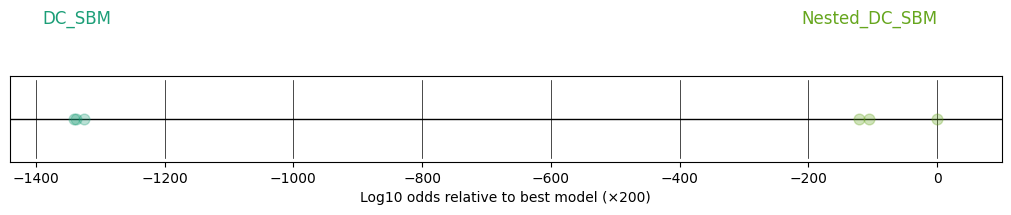

In [57]:
import os
os.makedirs("visual", exist_ok = True)

model_paths = {
    "DC_SBM": "models/dc_sbm_model.pickle",
    "Nested_DC_SBM": "models/nested_dc_sbm_model.pickle"
}

entropies = load_models(model_paths)
log_odds = compute_log_odds(entropies)
plot_model_comparison(log_odds, "visual/figure2_model_comparison.pdf")